# ¿Por qué usamos StandardScaler?

`StandardScaler` no es magia ni mejora todos los modelos por default.

Sirve para poner las variables en una escala comparable:

$$
z = \frac{x - \text{promedio}}{\text{desviación estándar}}
$$

Después de escalar:

- una variable tiene promedio cercano a 0,
- desviación estándar cercana a 1,
- y sus unidades dejan de dominar el algoritmo.

En esta clase veremos dos razones fuertes para usarlo:

1. modelos que usan distancias,
2. modelos con regularización como Ridge y Lasso.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. El problema: variables con unidades muy distintas

Supón que queremos predecir el precio de una casa usando:

- `metros_cuadrados`: valores como 50, 100, 200.
- `habitaciones`: valores como 1, 2, 3, 4.

Aunque ambas variables importan, `metros_cuadrados` tiene números mucho más grandes.


In [17]:
n = 120

metros = np.random.normal(120, 35, n).clip(35, 260)
habitaciones = np.round(metros / 45 + np.random.normal(0, 0.7, n)).clip(1, 7)

precio = (
    600_000
    + 18_000 * metros
    + 180_000 * habitaciones
    + np.random.normal(0, 350_000, n)
)

df = pd.DataFrame({
    'metros_cuadrados': metros,
    'habitaciones': habitaciones,
    'precio': precio,
})

df.head()


,metros_cuadrados,habitaciones,precio
0,137.384995,4.0,3.515548e+06
1,115.160749,2.0,2.992736e+06
2,142.669099,4.0,4.064789e+06
3,173.306045,3.0,4.562523e+06
4,111.804632,3.0,2.732380e+06


In [18]:
df[['metros_cuadrados', 'habitaciones']].describe().round(2)


,metros_cuadrados,habitaciones
count,120.00,120.00
mean,117.28,2.67
std,32.24,1.05
min,35.00,1.00
25%,99.98,2.00
50%,117.44,3.00
75%,133.40,3.00
max,206.21,6.00


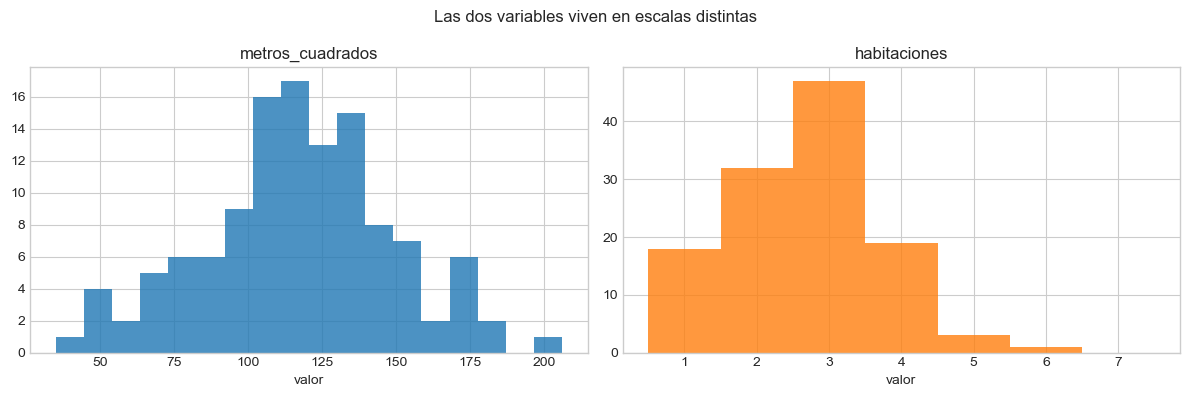

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['metros_cuadrados'], bins=18, color='tab:blue', alpha=0.8)
axes[0].set_title('metros_cuadrados')
axes[0].set_xlabel('valor')

axes[1].hist(df['habitaciones'], bins=np.arange(0.5, 8.5, 1), color='tab:orange', alpha=0.8)
axes[1].set_title('habitaciones')
axes[1].set_xlabel('valor')

plt.suptitle('Las dos variables viven en escalas distintas')
plt.tight_layout()
plt.show()


## 2. Qué hace StandardScaler

`StandardScaler` transforma cada columna por separado.

A cada valor le resta el promedio de su columna y lo divide entre su desviación estándar.

Eso convierte los valores a una pregunta más comparable:

> ¿Cuántas desviaciones estándar está este dato arriba o abajo del promedio?


In [20]:
scaler = StandardScaler()

X = df[['metros_cuadrados', 'habitaciones']]
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=['metros_escalados', 'habitaciones_escaladas'])
df_scaled.head()


,metros_escalados,habitaciones_escaladas
0,0.626124,1.277753
1,-0.066166,-0.638877
2,0.790725,1.277753
3,1.745072,0.319438
4,-0.170710,0.319438


In [21]:
resumen = pd.DataFrame({
    'promedio antes': X.mean(),
    'desv_est antes': X.std(),
    'promedio después': df_scaled.mean().values,
    'desv_est después': df_scaled.std().values,
})

resumen.round(3)


,promedio antes,desv_est antes,promedio después,desv_est después
metros_cuadrados,117.285,32.237,-0.0,1.004
habitaciones,2.667,1.048,0.0,1.004


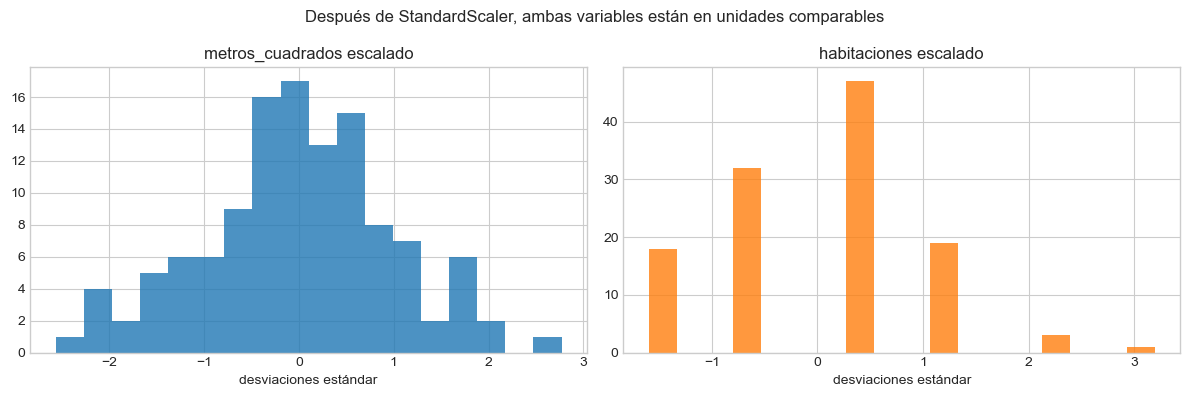

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_scaled['metros_escalados'], bins=18, color='tab:blue', alpha=0.8)
axes[0].set_title('metros_cuadrados escalado')
axes[0].set_xlabel('desviaciones estándar')

axes[1].hist(df_scaled['habitaciones_escaladas'], bins=18, color='tab:orange', alpha=0.8)
axes[1].set_title('habitaciones escalado')
axes[1].set_xlabel('desviaciones estándar')

plt.suptitle('Después de StandardScaler, ambas variables están en unidades comparables')
plt.tight_layout()
plt.show()


## 3. Ejemplo fuerte: descenso en gradiente

Con lo que ya hemos visto, hay una razón muy natural para escalar: **descenso en gradiente**.

Si una variable tiene valores alrededor de 100 o 200 y otra tiene valores alrededor de 1 o 5, los gradientes pueden quedar en tamaños muy diferentes. Entonces el algoritmo avanza más cómodo en una dirección que en otra.


In [23]:
# Usaremos dos variables para predecir precio.
X = df[['metros_cuadrados', 'habitaciones']].copy()
y = df['precio'].values

# Versión sin escalar
X_raw = X.values

# Versión escalada
scaler_gd = StandardScaler()
X_scaled_gd = scaler_gd.fit_transform(X)

def preparar_con_intercepto(X):
    return np.c_[np.ones(X.shape[0]), X]

X_raw_b = preparar_con_intercepto(X_raw)
X_scaled_b = preparar_con_intercepto(X_scaled_gd)

# Escalamos y también para que la pérdida sea más fácil de comparar.
y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std


In [24]:
def descenso_gradiente(X, y, learning_rate, iteraciones):
    m = len(y)
    beta = np.zeros(X.shape[1])
    perdidas = []

    for _ in range(iteraciones):
        pred = X @ beta
        error = pred - y
        perdida = np.mean(error ** 2)
        gradiente = (2 / m) * (X.T @ error)
        beta = beta - learning_rate * gradiente
        perdidas.append(perdida)

    return beta, np.array(perdidas)

beta_raw, perdidas_raw = descenso_gradiente(
    X_raw_b,
    y_scaled,
    learning_rate=0.00001,
    iteraciones=250
)

beta_scaled, perdidas_scaled = descenso_gradiente(
    X_scaled_b,
    y_scaled,
    learning_rate=0.08,
    iteraciones=250
)


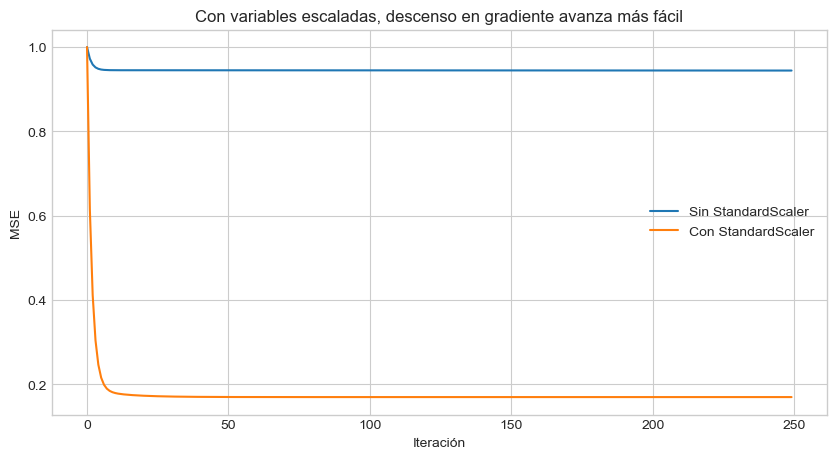

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(perdidas_raw, label='Sin StandardScaler')
plt.plot(perdidas_scaled, label='Con StandardScaler')
plt.xlabel('Iteración')
plt.ylabel('MSE')
plt.title('Con variables escaladas, descenso en gradiente avanza más fácil')
plt.legend()
plt.show()


La comparación no significa que sea imposible entrenar sin escalar.

Significa algo más práctico:

> cuando las variables están en escalas parecidas, es más fácil elegir una tasa de aprendizaje que funcione bien para todas.

Por eso `StandardScaler` aparece tanto antes de modelos entrenados con optimización numérica.
